## Backward Calculation of Implied Probabilities - Start: NOV 2025

In [23]:
import pandas as pd
import numpy as np

cme_nov_2025 = pd.read_csv("../../data/raw/CME/CME_NOV_2025.csv")
cme_nov_2025 = cme_nov_2025.reset_index(drop = True)
cme_nov_2025["time"] = pd.to_datetime(cme_nov_2025["time"],unit="s") 

In [24]:
cme_nov_2025

,time,open,high,low,close,Volume
0,2025-07-16 18:59:00,95.9550,95.9550,95.9550,95.9550,1434
1,2025-07-16 19:00:00,95.9550,95.9550,95.9550,95.9550,1
2,2025-07-16 19:02:00,95.9550,95.9550,95.9550,95.9550,832
3,2025-07-16 19:12:00,95.9550,95.9550,95.9550,95.9550,40
4,2025-07-16 19:13:00,95.9550,95.9550,95.9550,95.9550,32
...,...,...,...,...,...,...
19994,2025-11-27 23:04:00,96.1225,96.1225,96.1225,96.1225,8
19995,2025-11-28 15:31:00,96.1250,96.1250,96.1250,96.1250,15
19996,2025-11-28 15:43:00,96.1225,96.1225,96.1225,96.1225,63
19997,2025-11-28 16:50:00,96.1225,96.1225,96.1225,96.1225,3


## CME End: Jul 2025

In [25]:
cme_oct_2025 = pd.read_csv("../../data/raw/CME/CME_oct_2025.csv")
cme_oct_2025 = cme_oct_2025.reset_index(drop = True)
cme_oct_2025["time"] = pd.to_datetime(cme_oct_2025["time"],unit="s") 

In [26]:
cme_oct_2025

,time,open,high,low,close,Volume
0,2025-06-23 14:48:00,95.9350,95.9350,95.9350,95.9350,1
1,2025-06-23 14:49:00,95.9350,95.9350,95.9350,95.9350,1
2,2025-06-23 14:50:00,95.9350,95.9400,95.9350,95.9350,668
3,2025-06-23 14:51:00,95.9300,95.9350,95.9300,95.9300,106
4,2025-06-23 14:53:00,95.9350,95.9350,95.9350,95.9350,1
...,...,...,...,...,...,...
19994,2025-10-31 14:02:00,95.9125,95.9125,95.9125,95.9125,60
19995,2025-10-31 15:37:00,95.9125,95.9125,95.9125,95.9125,4
19996,2025-10-31 17:12:00,95.9100,95.9100,95.9100,95.9100,1
19997,2025-10-31 17:49:00,95.9100,95.9100,95.9100,95.9100,74


## Merge

In [27]:
nov = cme_nov_2025.copy()
nov["time"] = pd.to_datetime(nov["time"], unit="s")

if nov["time"].dt.tz is None:
    nov["time"] = nov["time"].dt.tz_localize("UTC")
else:
    nov["time"] = nov["time"].dt.tz_convert("UTC")

nov = nov.sort_values("time").set_index("time")
nov = nov.add_suffix("_nov_2025")

oct = cme_oct_2025.copy()
oct["time"] = pd.to_datetime(oct["time"], unit="s")

if oct["time"].dt.tz is None:
    oct["time"] = oct["time"].dt.tz_localize("UTC")
else:
    oct["time"] = oct["time"].dt.tz_convert("UTC")

oct = oct.sort_values("time").set_index("time")
oct = oct.add_suffix("_oct_2025")

In [28]:
final_df = nov.join(oct, how="left")

In [29]:
final_df = final_df.dropna()

In [30]:
final_df = final_df.reset_index()

In [31]:
final_df

,time,open_nov_2025,high_nov_2025,low_nov_2025,close_nov_2025,Volume_nov_2025,open_oct_2025,high_oct_2025,low_oct_2025,close_oct_2025,Volume_oct_2025
0,2025-07-16 19:00:00+00:00,95.955,95.955,95.955,95.955,1,95.8250,95.8250,95.8250,95.8250,8.0
1,2025-07-16 19:02:00+00:00,95.955,95.955,95.955,95.955,832,95.8250,95.8250,95.8250,95.8250,1.0
2,2025-07-16 19:26:00+00:00,95.955,95.955,95.955,95.955,87,95.8250,95.8250,95.8250,95.8250,1.0
3,2025-07-16 19:50:00+00:00,95.955,95.955,95.955,95.955,58,95.8250,95.8250,95.8250,95.8250,250.0
4,2025-07-16 20:46:00+00:00,95.955,95.955,95.955,95.955,34,95.8300,95.8300,95.8300,95.8300,300.0
...,...,...,...,...,...,...,...,...,...,...,...
8129,2025-10-30 20:59:00+00:00,96.115,96.115,96.115,96.115,34,95.9100,95.9100,95.9100,95.9100,24.0
8130,2025-10-31 11:49:00+00:00,96.115,96.115,96.115,96.115,96,95.9100,95.9100,95.9100,95.9100,400.0
8131,2025-10-31 12:15:00+00:00,96.115,96.115,96.115,96.115,14,95.9125,95.9125,95.9125,95.9125,10.0
8132,2025-10-31 14:02:00+00:00,96.120,96.120,96.120,96.120,60,95.9125,95.9125,95.9125,95.9125,60.0


## Calculate Implied Probabilities

In [32]:
meeting_day = 29
days_in_oct = 31

N = meeting_day           
M = days_in_oct - N        

imp_df = pd.DataFrame()
imp_df["time"] = final_df["time"].copy()

imp_df["effr_avg_oct"] = 100 - final_df["close_oct_2025"]
imp_df["effr_avg_nov"] = 100 - final_df["close_nov_2025"]

imp_df["effr_start_nov"] = imp_df["effr_avg_nov"]
imp_df["effr_end_oct"] = imp_df["effr_start_nov"]
imp_df["volume"] = final_df["Volume_oct_2025"]


In [33]:
imp_df["effr_start_oct"] = (
    imp_df["effr_avg_oct"] - (M / (N + M)) * imp_df["effr_end_oct"]
) / (N / (N + M))

In [34]:
imp_df["delta_effr"] = imp_df["effr_end_oct"] - imp_df["effr_start_oct"]
imp_df["num_hikes"] = imp_df["delta_effr"] / 0.25

imp_df["hikes_floor"] = np.floor(imp_df["num_hikes"])
imp_df["hikes_decimal"] = imp_df["num_hikes"] - imp_df["hikes_floor"]

states = [-4, -3, -2, -1, 0, 1, 2, 3, 4]

state_to_col = {
    -4: "prob_cut_100",
    -3: "prob_cut_75",
    -2: "prob_cut_50",
    -1: "prob_cut_25",
     0: "prob_no_change",
     1: "prob_hike_25",
     2: "prob_hike_50",
     3: "prob_hike_75",
     4: "prob_hike_100"
}

for col in state_to_col.values():
    imp_df[col] = 0.0

for i, row in imp_df.iterrows():
    floor = int(row["hikes_floor"])
    decimal = row["hikes_decimal"]
    
    p_low = 1 - decimal
    p_high = decimal
    
    if floor in state_to_col:
        imp_df.at[i, state_to_col[floor]] += p_low

    if (floor + 1) in state_to_col:
        imp_df.at[i, state_to_col[floor + 1]] += p_high

In [35]:
imp_df["time"] = pd.to_datetime(imp_df["time"], utc=True)

In [36]:
imp_df

,time,effr_avg_oct,effr_avg_nov,effr_start_nov,effr_end_oct,volume,effr_start_oct,delta_effr,num_hikes,hikes_floor,hikes_decimal,prob_cut_100,prob_cut_75,prob_cut_50,prob_cut_25,prob_no_change,prob_hike_25,prob_hike_50,prob_hike_75,prob_hike_100
0,2025-07-16 19:00:00+00:00,4.1750,4.045,4.045,4.045,8.0,4.183966,-0.138966,-0.555862,-1.0,0.444138,0.0,0.0,0.0,0.555862,0.444138,0.0,0.0,0.0,0.0
1,2025-07-16 19:02:00+00:00,4.1750,4.045,4.045,4.045,1.0,4.183966,-0.138966,-0.555862,-1.0,0.444138,0.0,0.0,0.0,0.555862,0.444138,0.0,0.0,0.0,0.0
2,2025-07-16 19:26:00+00:00,4.1750,4.045,4.045,4.045,1.0,4.183966,-0.138966,-0.555862,-1.0,0.444138,0.0,0.0,0.0,0.555862,0.444138,0.0,0.0,0.0,0.0
3,2025-07-16 19:50:00+00:00,4.1750,4.045,4.045,4.045,250.0,4.183966,-0.138966,-0.555862,-1.0,0.444138,0.0,0.0,0.0,0.555862,0.444138,0.0,0.0,0.0,0.0
4,2025-07-16 20:46:00+00:00,4.1700,4.045,4.045,4.045,300.0,4.178621,-0.133621,-0.534483,-1.0,0.465517,0.0,0.0,0.0,0.534483,0.465517,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8129,2025-10-30 20:59:00+00:00,4.0900,3.885,3.885,3.885,24.0,4.104138,-0.219138,-0.876552,-1.0,0.123448,0.0,0.0,0.0,0.876552,0.123448,0.0,0.0,0.0,0.0
8130,2025-10-31 11:49:00+00:00,4.0900,3.885,3.885,3.885,400.0,4.104138,-0.219138,-0.876552,-1.0,0.123448,0.0,0.0,0.0,0.876552,0.123448,0.0,0.0,0.0,0.0
8131,2025-10-31 12:15:00+00:00,4.0875,3.885,3.885,3.885,10.0,4.101466,-0.216466,-0.865862,-1.0,0.134138,0.0,0.0,0.0,0.865862,0.134138,0.0,0.0,0.0,0.0
8132,2025-10-31 14:02:00+00:00,4.0875,3.880,3.880,3.880,60.0,4.101810,-0.221810,-0.887241,-1.0,0.112759,0.0,0.0,0.0,0.887241,0.112759,0.0,0.0,0.0,0.0


## Filter Based on Decision Date


In [37]:
fomc_2025_utc = {
    "January 2025": pd.Timestamp("2025-01-29 19:00:00", tz="UTC"),
    "March 2025": pd.Timestamp("2025-03-19 18:00:00", tz="UTC"),
    "May 2025": pd.Timestamp("2025-05-07 18:00:00", tz="UTC"),
    "June 2025": pd.Timestamp("2025-06-18 18:00:00", tz="UTC"),
    "July 2025": pd.Timestamp("2025-07-30 18:00:00", tz="UTC"),
    "September 2025": pd.Timestamp("2025-09-17 18:00:00", tz="UTC"),
    "October 2025": pd.Timestamp("2025-10-29 19:00:00", tz="UTC"),
    "December 2025": pd.Timestamp("2025-12-10 19:00:00", tz="UTC"),
}

In [38]:
def filter_up_to_announcement(df, announcement_dict):

    if df.empty:
        return df
    last_timestamp = df["time"].iloc[-1]
    last_month_year = last_timestamp.strftime("%B %Y")

    if last_month_year in announcement_dict:
        cutoff_time = announcement_dict[last_month_year]
        filtered_df = df[df["time"] <= cutoff_time]
        return filtered_df
    else:
        print(
            f"Warning: '{last_month_year}' not found in the announcement dictionary"
        )
        return df

In [39]:
imp_df_fil = filter_up_to_announcement(imp_df,fomc_2025_utc)

In [40]:
imp_df_fil

,time,effr_avg_oct,effr_avg_nov,effr_start_nov,effr_end_oct,volume,effr_start_oct,delta_effr,num_hikes,hikes_floor,hikes_decimal,prob_cut_100,prob_cut_75,prob_cut_50,prob_cut_25,prob_no_change,prob_hike_25,prob_hike_50,prob_hike_75,prob_hike_100
0,2025-07-16 19:00:00+00:00,4.1750,4.045,4.045,4.045,8.0,4.183966,-0.138966,-0.555862,-1.0,0.444138,0.0,0.0,0.0,0.555862,0.444138,0.0,0.0,0.0,0.0
1,2025-07-16 19:02:00+00:00,4.1750,4.045,4.045,4.045,1.0,4.183966,-0.138966,-0.555862,-1.0,0.444138,0.0,0.0,0.0,0.555862,0.444138,0.0,0.0,0.0,0.0
2,2025-07-16 19:26:00+00:00,4.1750,4.045,4.045,4.045,1.0,4.183966,-0.138966,-0.555862,-1.0,0.444138,0.0,0.0,0.0,0.555862,0.444138,0.0,0.0,0.0,0.0
3,2025-07-16 19:50:00+00:00,4.1750,4.045,4.045,4.045,250.0,4.183966,-0.138966,-0.555862,-1.0,0.444138,0.0,0.0,0.0,0.555862,0.444138,0.0,0.0,0.0,0.0
4,2025-07-16 20:46:00+00:00,4.1700,4.045,4.045,4.045,300.0,4.178621,-0.133621,-0.534483,-1.0,0.465517,0.0,0.0,0.0,0.534483,0.465517,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8110,2025-10-29 18:13:00+00:00,4.0875,3.880,3.880,3.880,27.0,4.101810,-0.221810,-0.887241,-1.0,0.112759,0.0,0.0,0.0,0.887241,0.112759,0.0,0.0,0.0,0.0
8111,2025-10-29 18:30:00+00:00,4.0875,3.885,3.885,3.885,2.0,4.101466,-0.216466,-0.865862,-1.0,0.134138,0.0,0.0,0.0,0.865862,0.134138,0.0,0.0,0.0,0.0
8112,2025-10-29 18:43:00+00:00,4.0900,3.885,3.885,3.885,10.0,4.104138,-0.219138,-0.876552,-1.0,0.123448,0.0,0.0,0.0,0.876552,0.123448,0.0,0.0,0.0,0.0
8113,2025-10-29 18:47:00+00:00,4.0875,3.885,3.885,3.885,25.0,4.101466,-0.216466,-0.865862,-1.0,0.134138,0.0,0.0,0.0,0.865862,0.134138,0.0,0.0,0.0,0.0


## Visualization

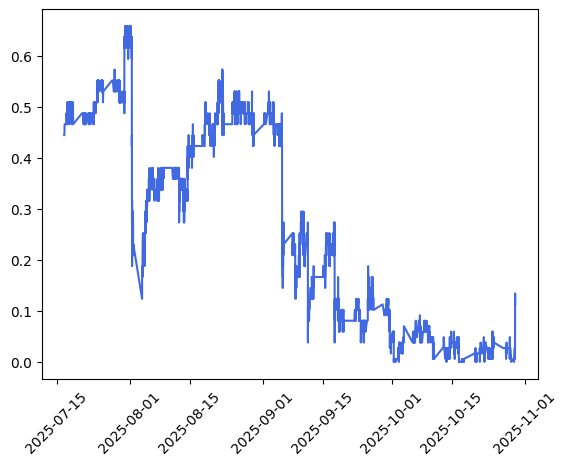

In [41]:
import matplotlib.pyplot as plt

plt.plot(imp_df_fil["time"],imp_df_fil['prob_no_change'], color='royalblue', linewidth=1.5)
plt.xticks(rotation=45)
plt.show()

## Export Data as CSV

In [42]:
import os
DATA_DIR = "../../data/processed/CME_implied_probabilities"
filename = "CME_IMP_OCT_2025.csv"
path = os.path.join(DATA_DIR, filename)
imp_df_fil.to_csv(path,index=False)